##  Exploratory Data Analysis (EDA)

###  Introduction

Before building any predictive model, it is essential to understand the structure and characteristics of the dataset. This notebook focuses on performing **Exploratory Data Analysis (EDA)** on the medical insurance dataset.

The dataset includes information about individuals such as demographic attributes, lifestyle factors, health indicators, and insurance-related variables.

---

###  Objective

The goal of this notebook is to:

- Understand the distribution of variables
- Identify missing values and potential data quality issues
- Detect outliers and skewness in numerical features
- Explore relationships between variables and the target (`annual_medical_cost`)
- Generate initial insights that will guide feature engineering and modeling steps

---

###  Why EDA Matters

A strong EDA helps:
- Reveal hidden patterns in the data
- Prevent incorrect modeling assumptions
- Improve model performance through better feature understanding

In [ ]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv("/content/medical_insurance.csv")

df.head(10)

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,27.4,Never,NaN,2,0,0,4,121.0,76.0,123.8,5.28,PPO,Bronze,1000,20,4,0,3.73,0.5714,6938.06,876.05,73.00,1,4672.59,4672.59,1,0,0,0,0,0,0,0,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,1,26.6,Never,Weekly,2,0,0,3,131.0,79.0,97.3,4.82,POS,Gold,1000,10,1,0,3.10,1.0000,1632.61,445.10,37.09,4,297.27,1189.08,2,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,3,31.5,Never,NaN,1,0,0,4,160.0,84.0,129.5,5.51,HMO,Platinum,500,20,10,0,3.90,1.0000,7661.01,1538.02,128.17,0,0.00,0.00,3,1,0,0,0,0,1,0,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,3,31.6,Never,NaN,0,0,0,1,104.0,68.0,160.3,8.50,HMO,Silver,500,20,5,0,3.89,0.2857,5130.27,820.63,68.39,0,0.00,0.00,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,0,30.5,Never,Daily,3,0,0,2,136.0,83.0,171.0,5.20,POS,Platinum,500,10,7,0,3.90,0.8681,1700.73,500.93,41.74,1,1002.24,1002.24,2,1,0,0,0,0,0,0,0,1,0,2,0,1,1,0,1,0
5,76435,63,Female,North,Rural,305000.0,HS,Single,Employed,3,2,20.4,Never,Daily,1,0,0,2,137.0,96.0,69.2,5.70,HMO,Silver,500,20,5,0,4.66,0.6923,2697.34,528.68,44.06,1,1220.04,1220.04,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0
6,84005,36,Male,West,Rural,38900.0,Masters,Single,Employed,1,0,21.6,Never,Occasional,0,0,0,0,114.0,76.0,153.9,5.54,HMO,Silver,500,10,3,0,4.30,0.1978,1746.68,414.60,34.55,0,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0
7,80918,21,Female,South,Suburban,83700.0,HS,Single,Employed,3,2,30.7,Never,Weekly,3,0,0,1,82.0,64.0,189.0,7.01,HMO,Gold,2000,20,6,0,4.65,0.3187,1564.03,445.22,37.10,2,703.03,1406.06,1,0,1,0,0,0,0,0,0,0,0,2,1,0,0,1,0,1
8,60768,53,Male,North,Suburban,60700.0,No HS,Divorced,Retired,1,0,27.8,Current,NaN,0,0,0,0,138.0,84.0,151.5,5.52,HMO,Gold,1000,10,4,0,4.38,0.8571,5684.12,1028.51,85.71,0,0.00,0.00,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0
9,50075,28,Male,South,Urban,23600.0,Bachelors,Married,Employed,4,2,31.0,Never,Weekly,0,0,0,0,99.0,62.0,108.6,4.49,EPO,Gold,500,10,4,0,3.24,0.1978,4150.00,802.60,66.88,0,0.00,0.00,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_theme(style="whitegrid")

In [ ]:
df.shape

(100000, 54)

In [ ]:
df.dtypes

,0
person_id,int64
age,int64
sex,object
region,object
urban_rural,object
income,float64
education,object
marital_status,object
employment_status,object
household_size,int64


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_id,100000.0,50000.500000,28867.657797,1.00,25000.7500,50000.5000,75000.2500,100000.00
age,100000.0,47.521500,15.988752,0.00,37.0000,48.0000,58.0000,100.00
income,100000.0,49873.905000,46800.214127,1100.00,21100.0000,36200.0000,62200.0000,1061800.00
household_size,100000.0,2.430900,1.075126,1.00,2.0000,2.0000,3.0000,9.00
dependents,100000.0,0.898380,0.950654,0.00,0.0000,1.0000,1.0000,7.00
bmi,100000.0,26.990512,4.994883,12.00,23.6000,27.0000,30.4000,50.40
visits_last_year,100000.0,1.927650,1.737730,0.00,1.0000,2.0000,3.0000,25.00
hospitalizations_last_3yrs,100000.0,0.093640,0.304848,0.00,0.0000,0.0000,0.0000,3.00
days_hospitalized_last_3yrs,100000.0,0.373350,1.373011,0.00,0.0000,0.0000,0.0000,21.00
medication_count,100000.0,1.236320,1.209358,0.00,0.0000,1.0000,2.0000,11.00


## Check for missing values

In [ ]:
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values[missing_values > 0])

Missing Values:
 alcohol_freq    30083
dtype: int64


There are missing values only in the `alcohol_freq` variable. Let's look at the proportion of missing values in that variable.

In [ ]:
missing_count = df['alcohol_freq'].isnull().sum()
total_count = len(df)
missing_percentage = (missing_count / total_count) * 100
print(f" Proportion of missing values: %{missing_percentage:.2f}")

 Proportion of missing values: %30.08


##Target Variable Analysis

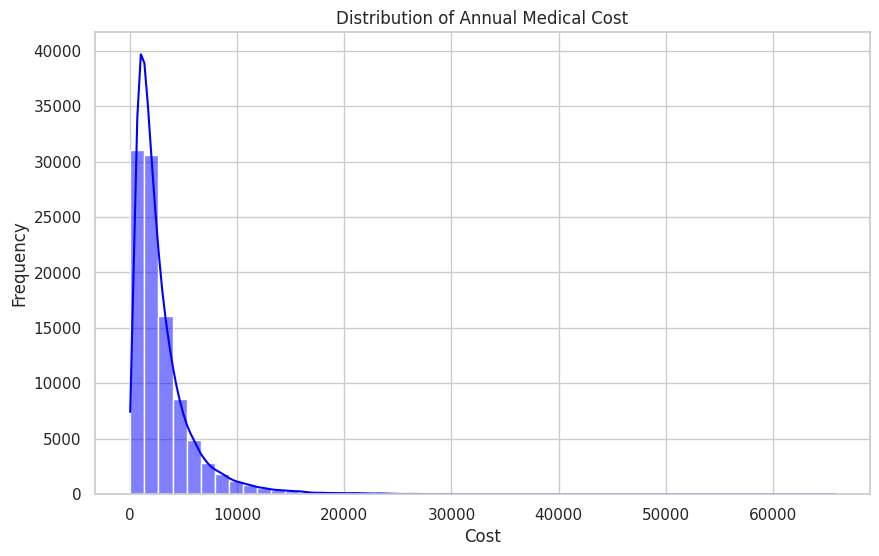

Skewness of annual_medical_cost: 4.030


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['annual_medical_cost'], kde=True, bins=50, color='blue')
plt.title('Distribution of Annual Medical Cost')
plt.xlabel('Cost')
plt.ylabel('Frequency')
plt.show()

# Calculate skewness
skewness = df['annual_medical_cost'].skew()
print(f"Skewness of annual_medical_cost: {skewness:.3f}")

### Target Variable Analysis: Annual Medical Cost

*   **Right-Skewed Distribution:** The target variable (`annual_medical_cost`) is highly right-skewed (Skewness: 4.030).
*   **Cost Concentration:** The vast majority of individuals incur relatively low annual medical costs (concentrated between \$0 and \$10,000).
*   **Long Tail (High Risk):** A small minority of individuals generate exceptionally high costs (the "long tail" reaching up to \$60,000+), which is typical for health insurance data.
*   **Next Steps for Modeling:** Due to the severe skewness, applying a **Log Transformation** to this variable during preprocessing will be crucial to normalize the distribution and improve the performance of our regression models.



##Numerical Variable Analysis

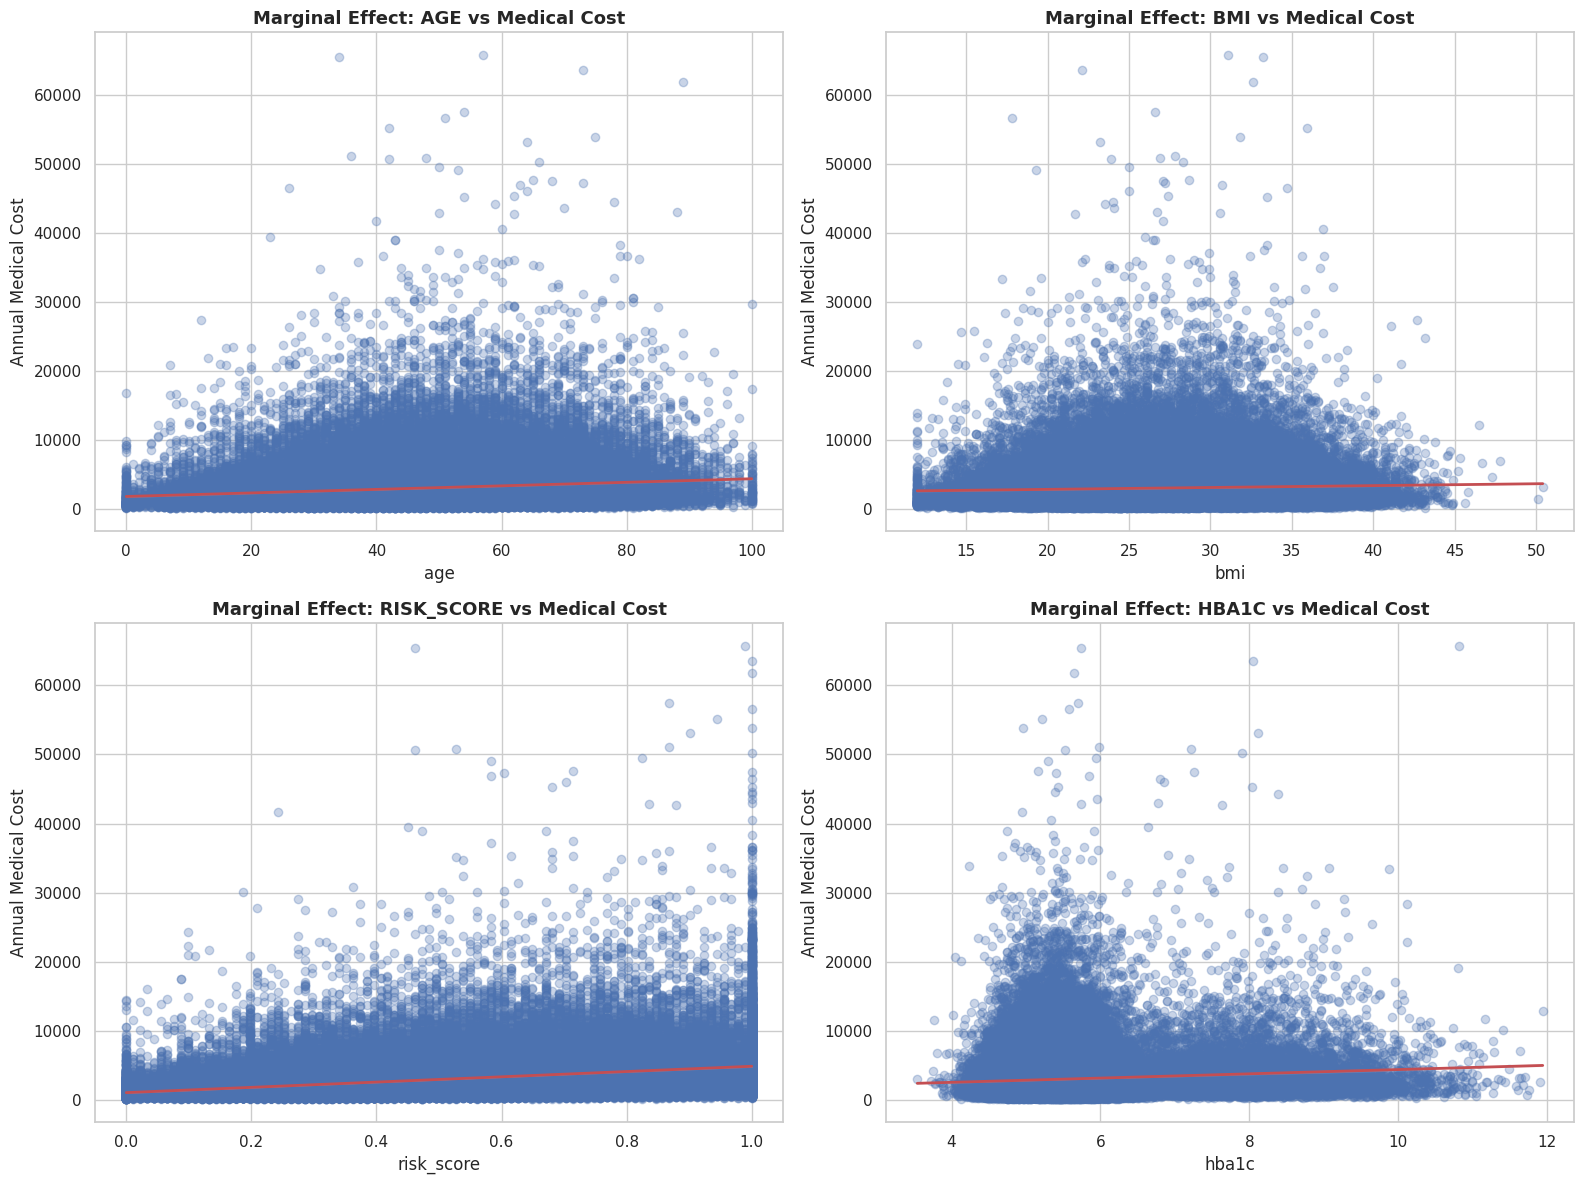

In [ ]:
# Cell for Advanced Numerical Variable Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

sns.set_theme(style="whitegrid")

# 1. Define target and identify potential Data Leakage columns to exclude
target = 'annual_medical_cost'
leakage_cols = ['annual_premium', 'monthly_premium', 'total_claims_paid', 'avg_claim_amount', 'person_id']

# Get relevant numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns
features = [col for col in num_cols if col not in leakage_cols and col != target]

# 2. Advanced Scatter Plots with Regression Lines (Linearity Check)
# Selecting key physiological/demographic variables
key_vars = ['age', 'bmi', 'risk_score', 'hba1c']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    # regplot adds a linear regression line with a 95% confidence interval
    sns.regplot(x=var, y=target, data=df, ax=axes[i],
                scatter_kws={'alpha':0.3, 'color':'#4C72B0'},
                line_kws={'color':'#C44E52', 'linewidth':2})

    axes[i].set_title(f'Marginal Effect: {var.upper()} vs Medical Cost', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Annual Medical Cost')

plt.tight_layout()
plt.show()



*   **Risk Score:** Shows the strongest positive linear trend. Higher risk scores clearly drive up base medical costs.
*   **Age & BMI:** Very weak linear relationships. The massive scatter shows that age or weight alone cannot reliably predict high medical bills.
*   **HbA1c:** The regression line is almost flat, indicating minimal direct linear correlation with annual costs.
*   **Conclusion:** Healthcare costs are too complex for simple linear models. The high variance means we need advanced algorithms to capture hidden interactions between these variables.

Calculating Random Forest Feature Importances...


/tmp/ipykernel_4011/567962969.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


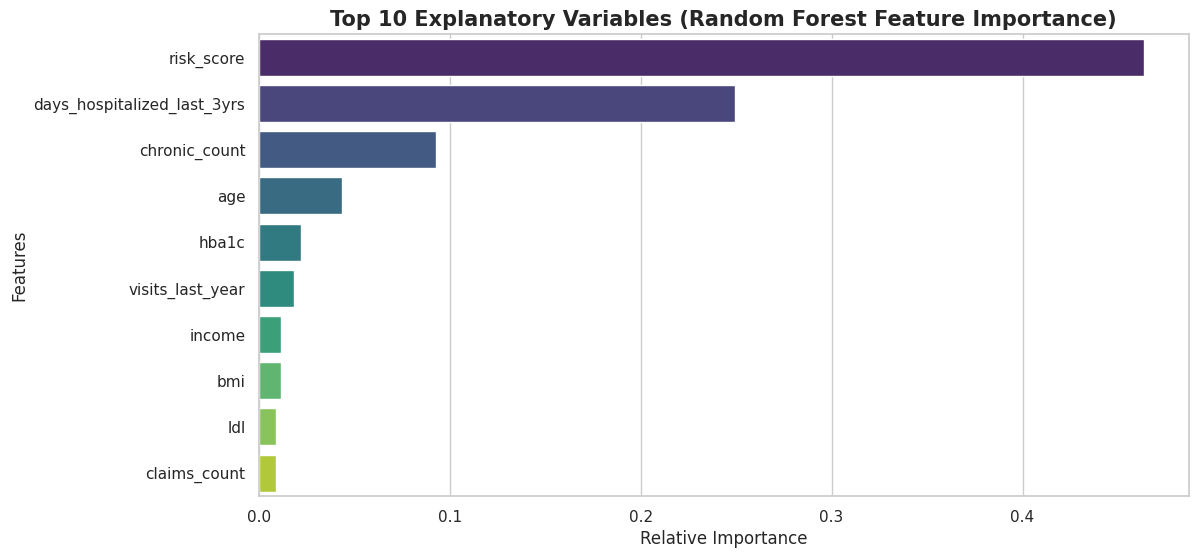

In [ ]:
# 3. Non-Linear Feature Importance using Random Forest
# This captures complex interactions that simple Pearson correlation misses
X = df[features].fillna(0) # Simple fill for EDA purposes only
y = df[target]

print("Calculating Random Forest Feature Importances...")
rf_eda = RandomForestRegressor(n_estimators=50, max_depth=6, random_state=42, n_jobs=-1)
rf_eda.fit(X, y)

# Extract and plot importances
importances = pd.Series(rf_eda.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Top 10 Explanatory Variables (Random Forest Feature Importance)', fontsize=15, fontweight='bold')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.show()

*   **The Undisputed Driver:** `risk_score` is the overwhelmingly dominant predictor, accounting for nearly half of the model's decision-making weight.
*   **Historical Usage is Key:** `days_hospitalized_last_3yrs` is the second strongest feature. Past hospital utilization is a massive indicator of future annual medical costs.
*   **Secondary Factors:** `chronic_count` and `age` provide moderate predictive value, acting as the next tier of importance.
*   **Surprising Findings:** Specific physiological metrics (`bmi`, `ldl`, `hba1c`) show very low individual importance. This implies their financial impact is likely already summarized and captured within the overarching `risk_score`.

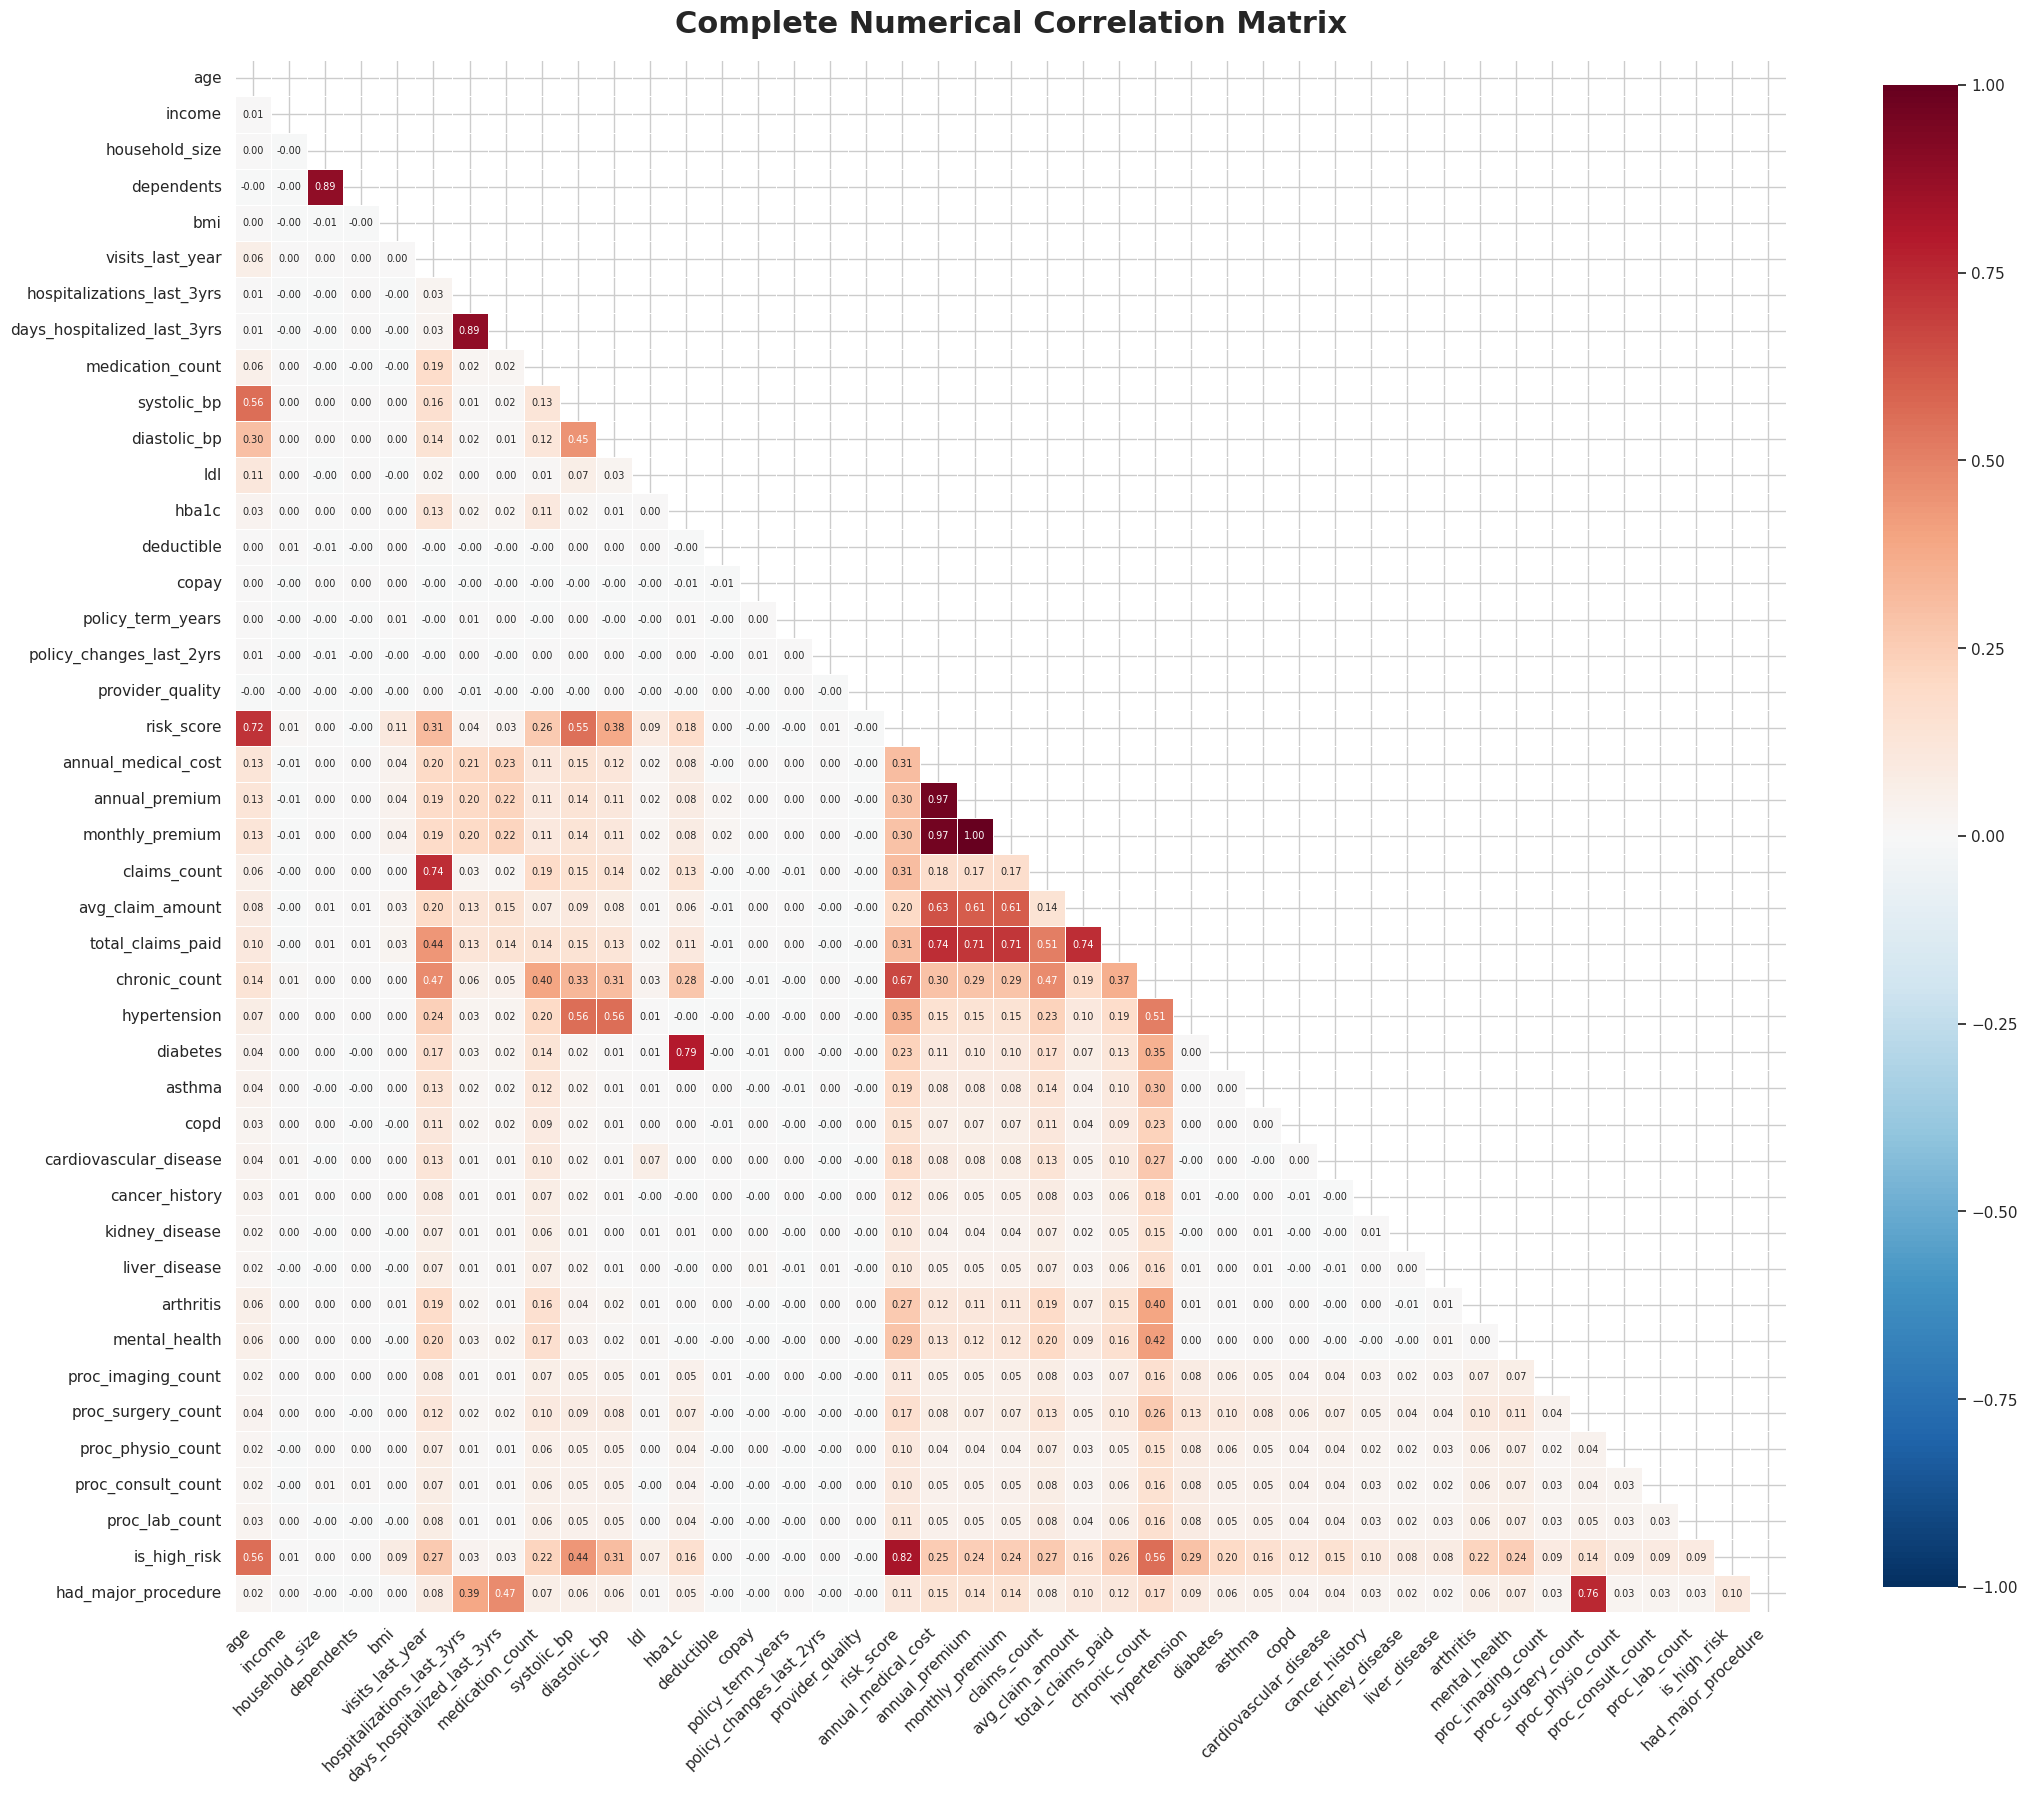

In [ ]:

num_df = df.select_dtypes(include=[np.number]).drop(columns=['person_id'])
corr = num_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(22, 20))
sns.heatmap(corr,
            mask=mask,
            cmap='RdBu_r',
            vmax=1, vmin=-1, center=0,
            annot=True,
            fmt='.2f',
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .8},
            annot_kws={"size": 7})

plt.title('Complete Numerical Correlation Matrix', fontsize=22, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

##Comprehensive Categorical Analysis

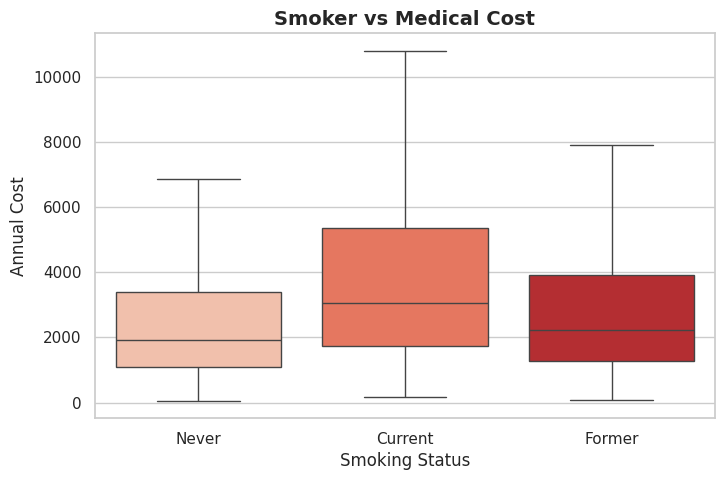

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='annual_medical_cost', data=df, hue='smoker', palette='Reds', legend=False, showfliers=False)
plt.title('Smoker vs Medical Cost', fontsize=14, fontweight='bold')
plt.ylabel('Annual Cost')
plt.xlabel('Smoking Status')
plt.show()

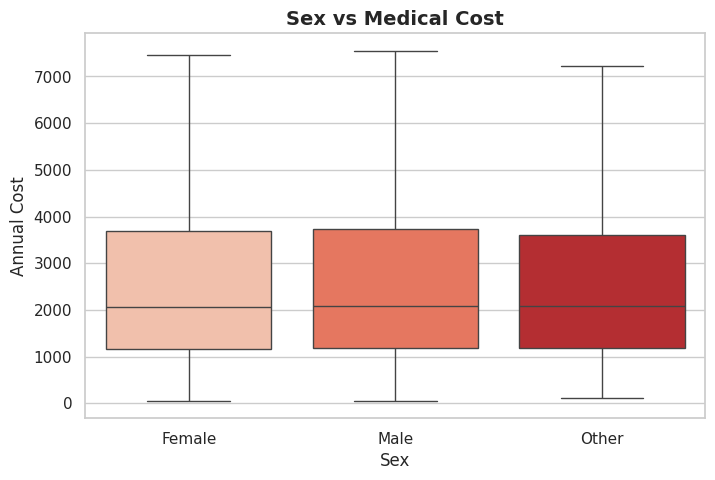

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='sex', y='annual_medical_cost', data=df, hue='sex', palette='Reds', legend=False, showfliers=False)
plt.title('Sex vs Medical Cost', fontsize=14, fontweight='bold')
plt.ylabel('Annual Cost')
plt.xlabel('Sex')
plt.show()

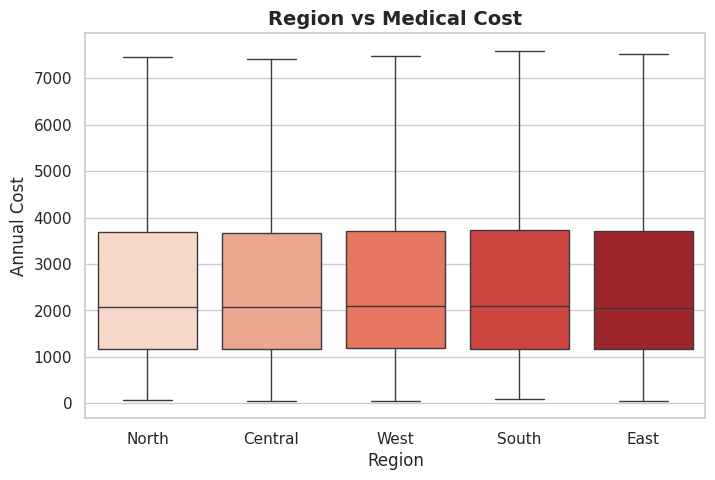

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='region', y='annual_medical_cost', data=df, hue='region', palette='Reds', legend=False, showfliers=False)
plt.title('Region vs Medical Cost', fontsize=14, fontweight='bold')
plt.ylabel('Annual Cost')
plt.xlabel('Region')
plt.show()

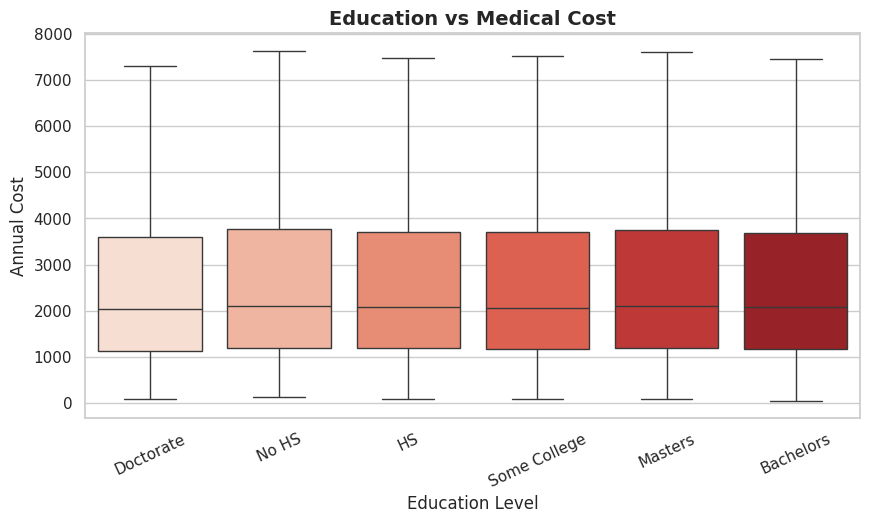

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='education', y='annual_medical_cost', data=df, hue='education', palette='Reds', legend=False, showfliers=False)
plt.title('Education vs Medical Cost', fontsize=14, fontweight='bold')
plt.tick_params(axis='x', rotation=25)
plt.ylabel('Annual Cost')
plt.xlabel('Education Level')
plt.show()

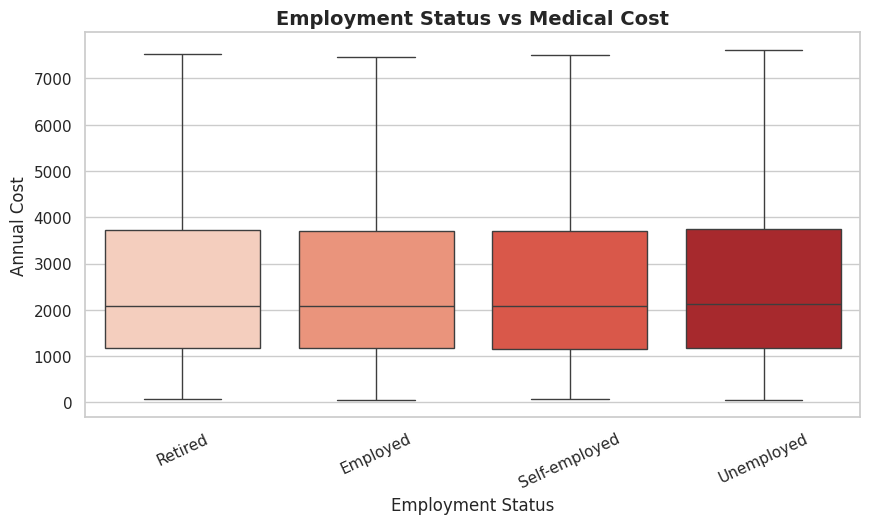

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='employment_status', y='annual_medical_cost', data=df, hue='employment_status', palette='Reds', legend=False, showfliers=False)
plt.title('Employment Status vs Medical Cost', fontsize=14, fontweight='bold')
plt.tick_params(axis='x', rotation=25)
plt.ylabel('Annual Cost')
plt.xlabel('Employment Status')
plt.show()

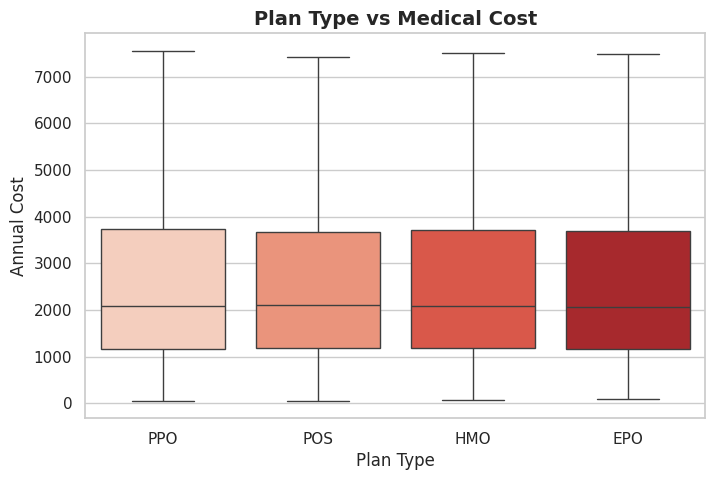

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='plan_type', y='annual_medical_cost', data=df, hue='plan_type', palette='Reds', legend=False, showfliers=False)
plt.title('Plan Type vs Medical Cost', fontsize=14, fontweight='bold')
plt.ylabel('Annual Cost')
plt.xlabel('Plan Type')
plt.show()

### Plan Type

The abbreviations in this variable represent standard administrative policy structures used in the health insurance industry:

*   **HMO (Health Maintenance Organization):** The most restrictive plan. It requires a Primary Care Physician (PCP) to coordinate care, and a **referral** is mandatory to see a specialist. It generally only covers "in-network" providers.
*   **PPO (Preferred Provider Organization):** The most flexible plan. No referrals are needed to see specialists, and it provides partial coverage for "out-of-network" providers.
*   **EPO (Exclusive Provider Organization):** A hybrid between PPO and HMO. No referrals are required (flexible like PPO), but it generally does not cover out-of-network care at all (strict like HMO).
*   **POS (Point of Service):** Another hybrid model. It requires a PCP and referrals (like HMO) but allows the patient to go out-of-network for a higher out-of-pocket cost (like PPO).



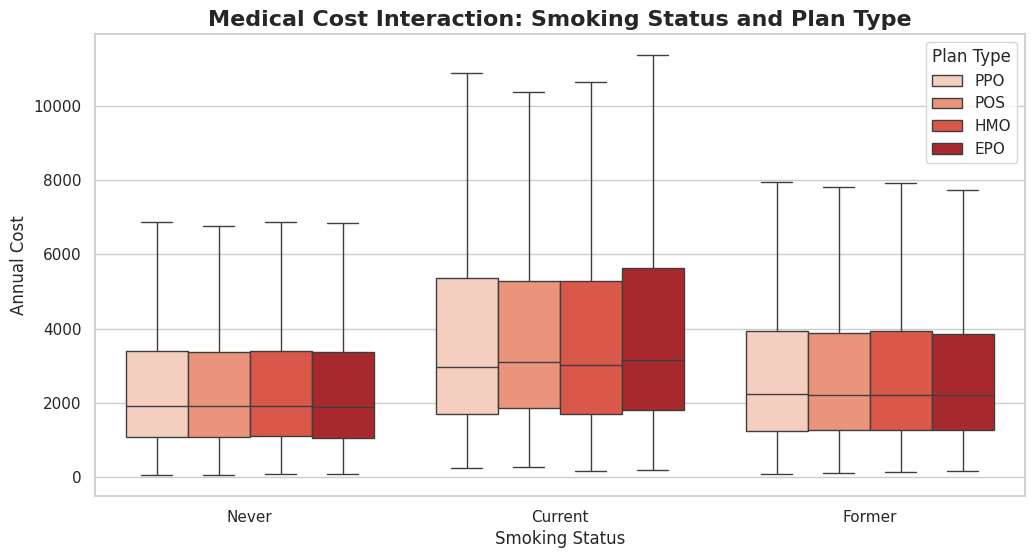

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='smoker', y='annual_medical_cost', hue='plan_type', data=df, palette='Reds', showfliers=False)
plt.title('Medical Cost Interaction: Smoking Status and Plan Type', fontsize=16, fontweight='bold')
plt.ylabel('Annual Cost')
plt.xlabel('Smoking Status')
plt.legend(title='Plan Type')
plt.show()

## Outlier Detection

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns
print(num_cols)

Index(['person_id', 'age', 'income', 'household_size', 'dependents', 'bmi',
       'visits_last_year', 'hospitalizations_last_3yrs',
       'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp',
       'diastolic_bp', 'ldl', 'hba1c', 'deductible', 'copay',
       'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality',
       'risk_score', 'annual_medical_cost', 'annual_premium',
       'monthly_premium', 'claims_count', 'avg_claim_amount',
       'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes',
       'asthma', 'copd', 'cardiovascular_disease', 'cancer_history',
       'kidney_disease', 'liver_disease', 'arthritis', 'mental_health',
       'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count',
       'proc_consult_count', 'proc_lab_count', 'is_high_risk',
       'had_major_procedure'],
      dtype='object')


In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    return {
        "column": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outliers.shape[0],
        "outlier_ratio (%)": round(100 * outliers.shape[0] / data.shape[0], 2)
    }

In [ ]:
outlier_summary = []

for col in num_cols:
    result = detect_outliers_iqr(df, col)
    outlier_summary.append(result)

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,column,lower_bound,upper_bound,outlier_count,outlier_ratio (%)
0,person_id,-49998.50000,149999.50000,0,0.00
1,age,5.50000,89.50000,864,0.86
2,income,-40550.00000,123850.00000,6236,6.24
3,household_size,0.50000,4.50000,4052,4.05
4,dependents,-1.50000,2.50000,6306,6.31
5,bmi,13.40000,40.60000,676,0.68
6,visits_last_year,-2.00000,6.00000,2083,2.08
7,hospitalizations_last_3yrs,0.00000,0.00000,8969,8.97
8,days_hospitalized_last_3yrs,0.00000,0.00000,8969,8.97
9,medication_count,-3.00000,5.00000,492,0.49


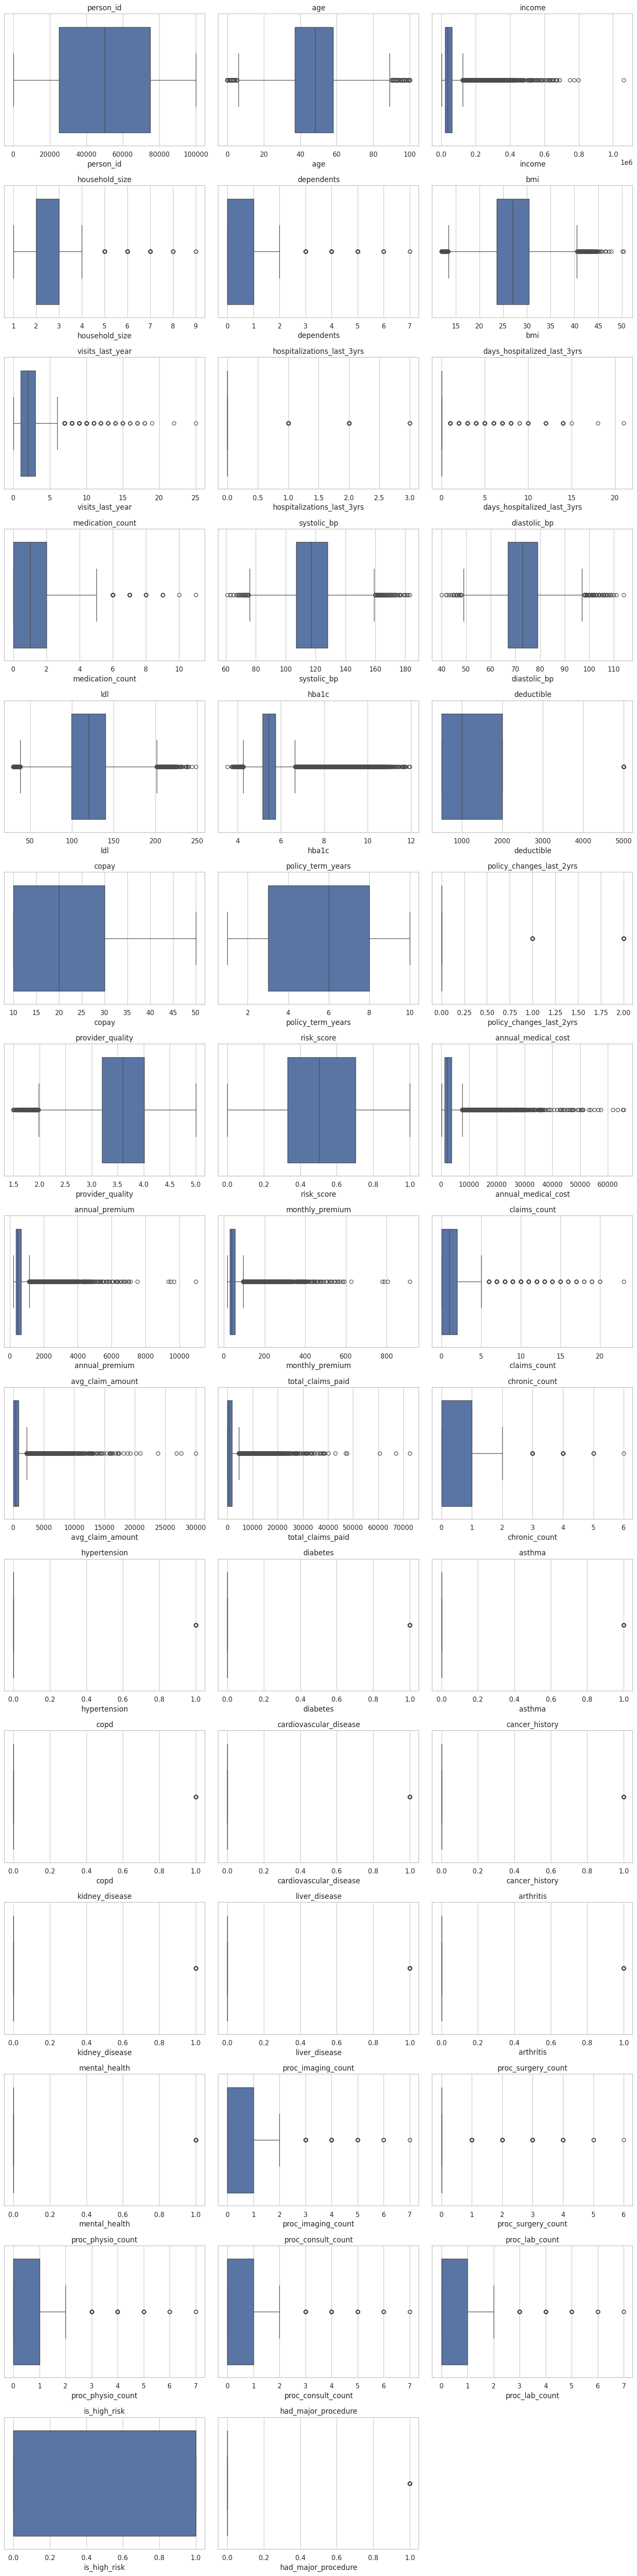

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Outlier Analysis Summary

From the boxplots above:

- Many numerical variables contain outliers (points outside the whiskers).
- Especially cost-related variables (premium, claim amounts) show extreme values.
- These outliers are mostly on the right side, indicating a right-skewed distribution.
- Some variables (like counts and binary features) naturally appear to have outliers, but this is expected.

### Key Insight

These outliers are not errors — they represent real high-cost or high-risk individuals.

### Decision

Outliers will not be removed at this stage, since they carry important information for prediction.

Outliers likely correspond to high-risk individuals and therefore contain valuable predictive information.

## Bivariate Analysis

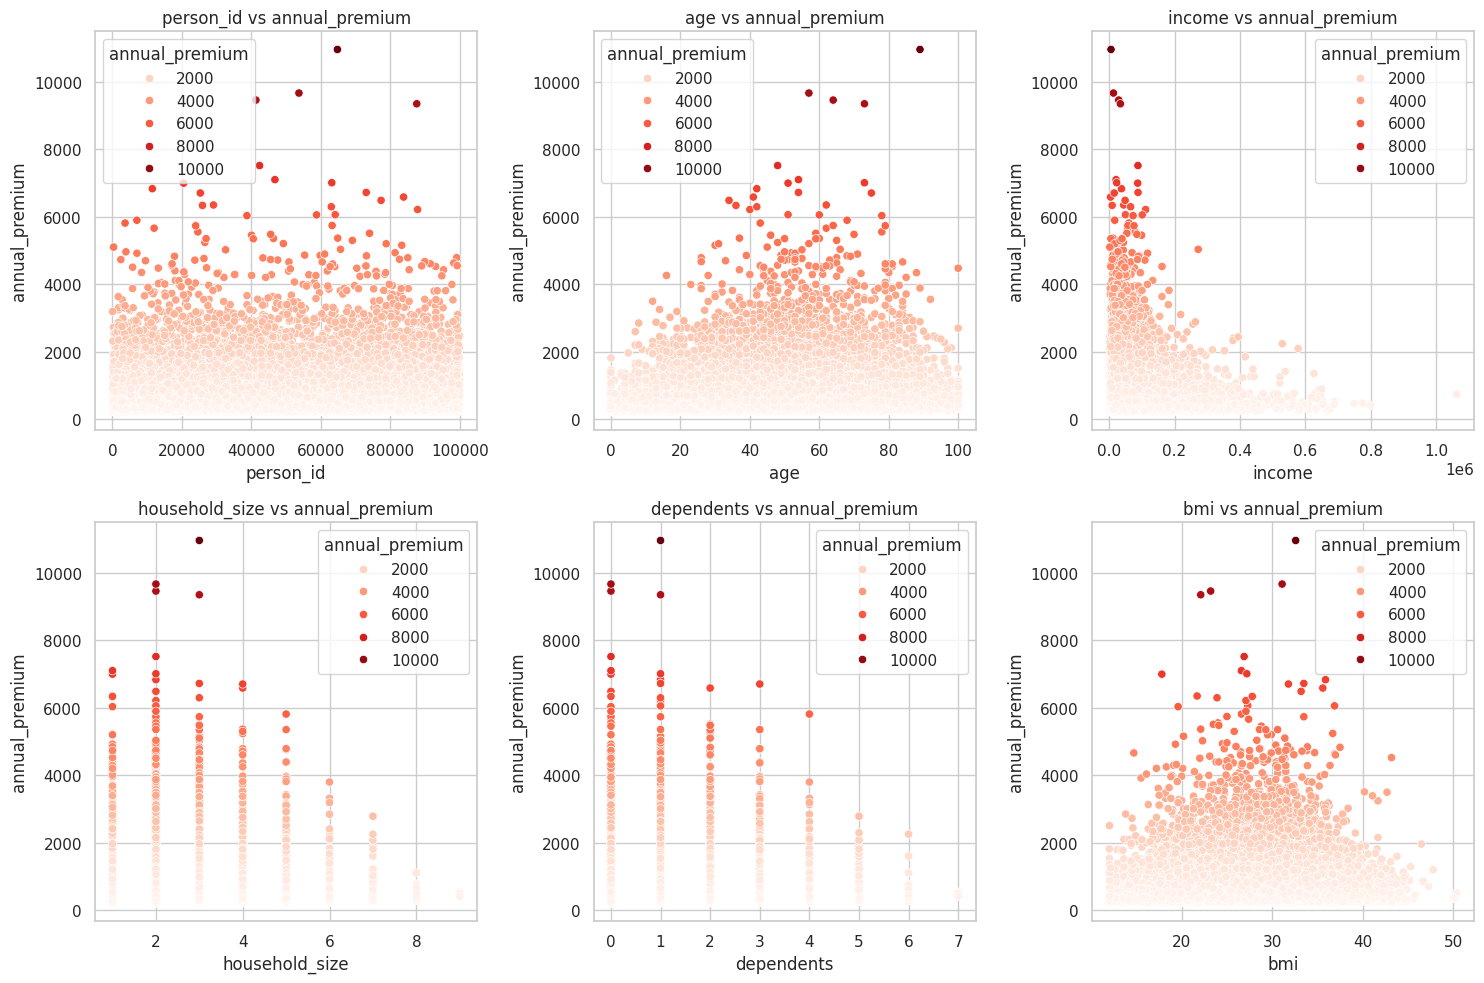

In [ ]:
target = "annual_premium"

num_cols = df.select_dtypes(include="number").columns
num_cols = [col for col in num_cols if col != target]

plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols[:6], 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=df[col], y=df[target], hue=df[target], palette='Reds')
    plt.title(f"{col} vs {target}")

plt.tight_layout()
plt.show()

### Bivariate Analysis Findings (Annual Premium)

- **Age vs Premium:** A slight positive relationship is observed — premiums tend to increase with age, but the relationship is not strongly linear.
- **BMI vs Premium:** There is a weak positive trend; higher BMI values are associated with somewhat higher premiums, though variability is high.
- **Income vs Premium:** No clear linear relationship. Most high premiums are concentrated at lower-to-mid income levels, indicating income alone is not a strong predictor.
- **Household Size & Dependents:** These variables show discrete patterns, but no strong impact on premium is evident.
- **Person ID:** No meaningful relationship (as expected, it's just an identifier).

### Key Insight

The relationships between features and annual premium are generally weak and non-linear, suggesting that simple linear models may struggle and more flexible models may perform better.

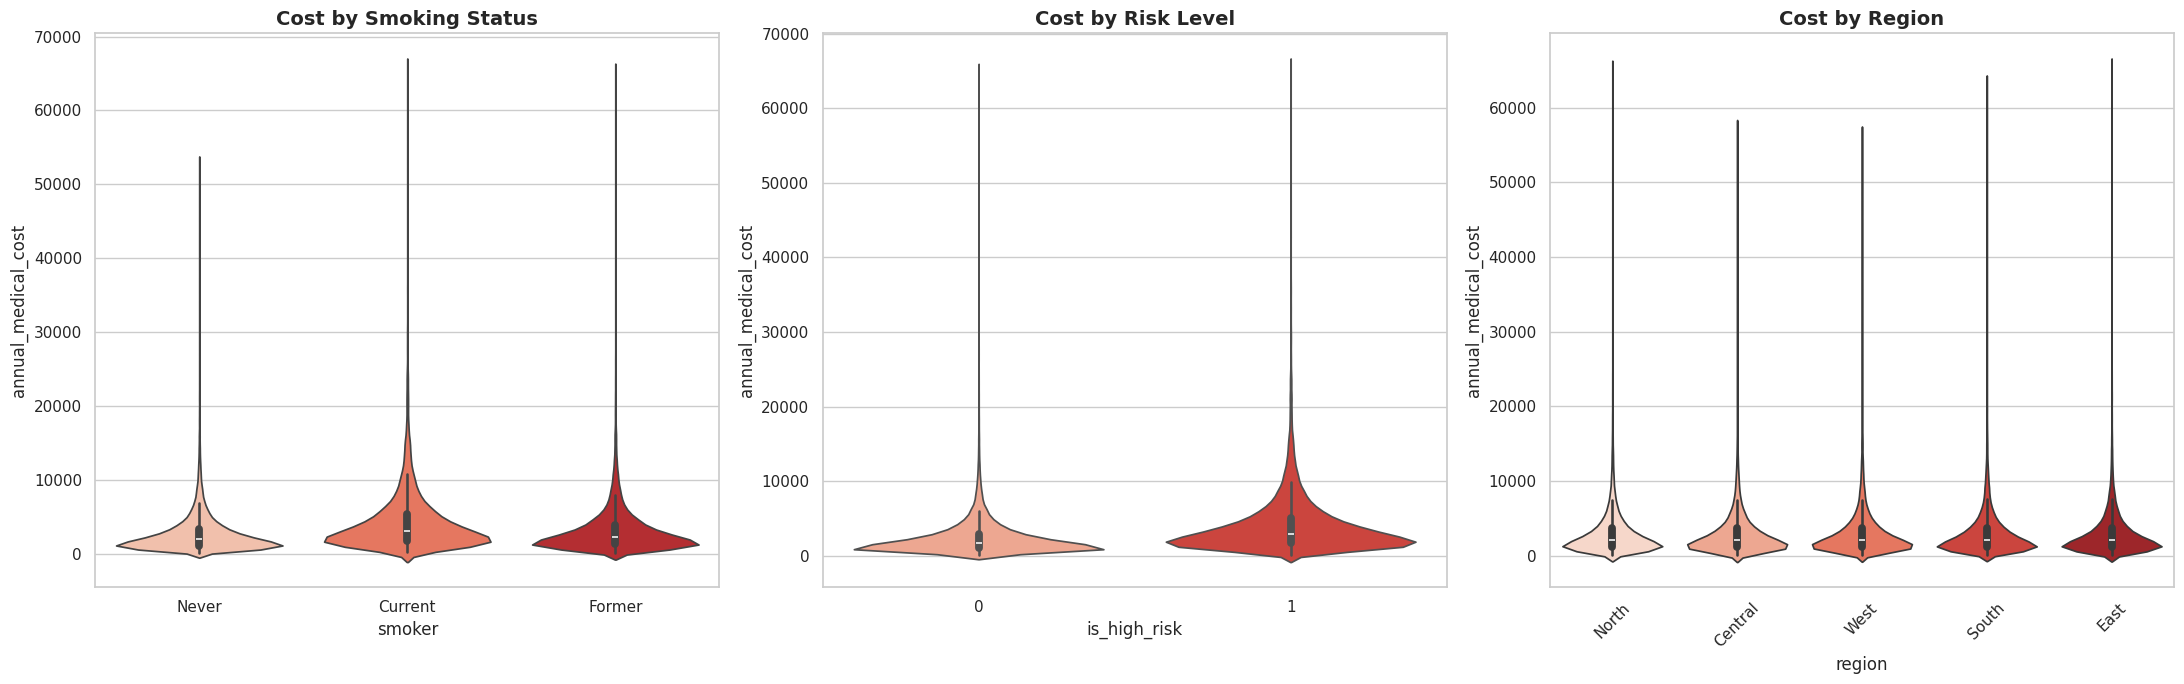

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

sns.violinplot(x="smoker", y="annual_medical_cost", data=df, ax=axes[0],
               hue="smoker", palette="Reds", legend=False)
axes[0].set_title("Cost by Smoking Status", fontsize=14, fontweight='bold')
sns.violinplot(x="is_high_risk", y="annual_medical_cost", data=df, ax=axes[1],
               hue="is_high_risk", palette="Reds", legend=False)
axes[1].set_title("Cost by Risk Level", fontsize=14, fontweight='bold')

sns.violinplot(x="region", y="annual_medical_cost", data=df, ax=axes[2],
               hue="region", palette="Reds", legend=False)
axes[2].set_title("Cost by Region", fontsize=14, fontweight='bold')
plt.sca(axes[2])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

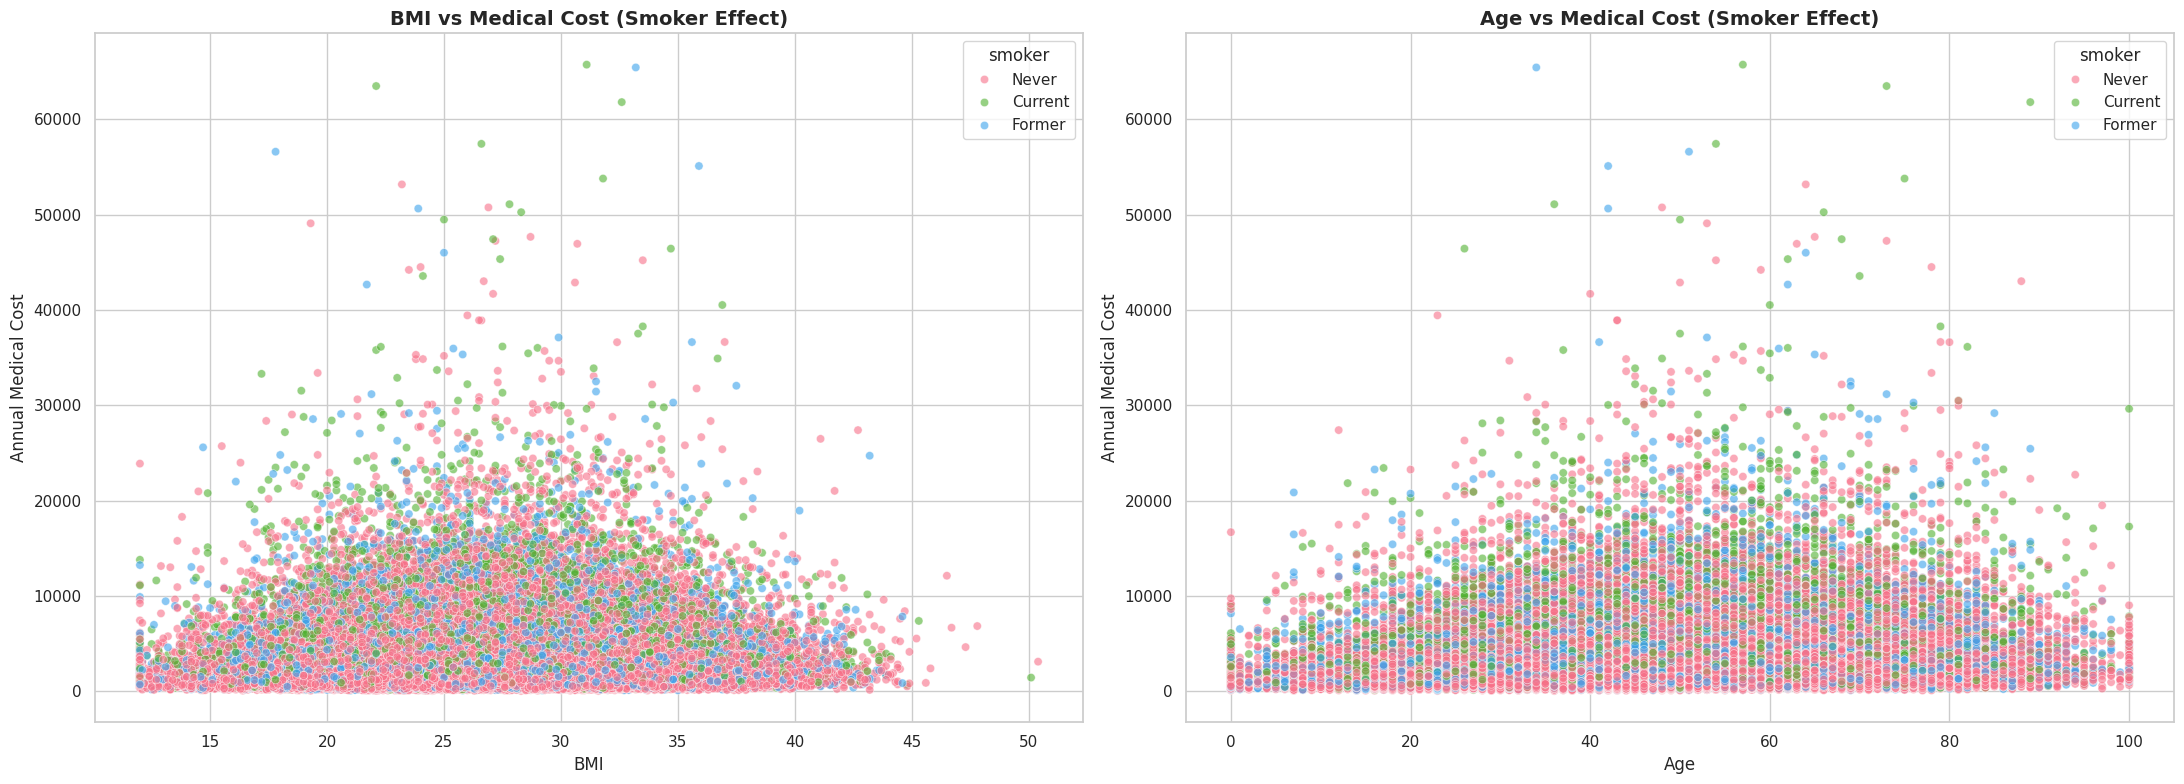

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.scatterplot(x="bmi", y="annual_medical_cost", hue="smoker", data=df, ax=axes[0], alpha=0.6, palette="husl")
axes[0].set_title("BMI vs Medical Cost (Smoker Effect)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Annual Medical Cost")

sns.scatterplot(x="age", y="annual_medical_cost", hue="smoker", data=df, ax=axes[1], alpha=0.6, palette="husl")
axes[1].set_title("Age vs Medical Cost (Smoker Effect)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Annual Medical Cost")

plt.tight_layout()
plt.show()

### Bivariate Analysis Findings (Smoker Effect)

- **BMI vs Medical Cost:** A weak positive relationship is observed between BMI and medical cost. However, smoker groups (especially current smokers) tend to have higher costs across almost all BMI levels.
- **Age vs Medical Cost:** Medical costs generally increase with age, but the relationship is not strictly linear. Older individuals show greater variability and higher extreme values.
- **Smoker Effect:** Smoking status creates a clear separation in cost levels. Current smokers consistently appear in higher cost regions, while non-smokers are mostly concentrated at lower cost levels.

### Key Insight

Smoking status is a strong driver of medical cost and amplifies the effect of other variables such as age and BMI.